# Model-Based Reinforcement Learning

## Daw Two-Step Task ([Daw et al., 2011, *Neuron*](https://doi.org/10.1016/j.neuron.2011.02.027))

This example demonstrates parameter recovery for the two-step Markov decision task of
Daw, Gershman, Seymour, Dayan & Dolan (2011). On each trial an agent makes a **first-stage**
choice between two options. Each option leads *predominantly* (70% of the time, a *common*
transition) to one of two **second-stage** states, and *rarely* (30%) to the other. At the
second stage the agent chooses again and receives a binary reward whose probability drifts
slowly according to independent Gaussian random walks (reflecting bounds $[0.25, 0.75]$).

The task dissociates two learning strategies. A **model-free** SARSA($\lambda$) learner
values first-stage actions by the reward that followed them, regardless of the transition
taken. A **model-based** learner instead uses a model of the transition structure to plan,
so a rare transition inverts the effect of a reward on the next first-stage choice. The
**hybrid** model mixes the two with a weight $\omega$ (Daw's $w$).

$$
\textbf{Model-free prediction errors:}\quad
\delta_1 = Q_2(s_2, a_2) - Q_1(s_1, a_1), \qquad
\delta_2 = r - Q_2(s_2, a_2) \tag{1}
$$

$$
\textbf{SARSA($\lambda$) updates:}\quad
Q_1(s_1, a_1) \leftarrow Q_1(s_1, a_1) + \alpha_1\,(\delta_1 + \lambda\,\delta_2), \qquad
Q_2(s_2, a_2) \leftarrow Q_2(s_2, a_2) + \alpha_2\,\delta_2 \tag{2}
$$

$$
\textbf{Model-based values (Bellman):}\quad
Q_{\text{MB}}(s_A, a) = \sum_{s'} P(s' \mid a)\,\max_{a'} Q_2(s', a') \tag{3}
$$

$$
\textbf{Net first-stage value:}\quad
Q_{\text{net}}(s_A, a) = \omega\,Q_{\text{MB}}(s_A, a) + (1 - \omega)\,Q_1(s_A, a) + r\cdot\text{rep}(a) \tag{4}
$$

$$
\textbf{Choice rule (softmax):}\quad
p_t(a_i \mid s_i) = \frac{\exp\!\big(\beta_i\,Q_{\text{net}}(s_i, a_i)\big)}{\sum_{a'} \exp\!\big(\beta_i\,Q_{\text{net}}(s_i, a')\big)} \tag{5}
$$

where $\text{rep}(a) = 1$ if $a$ is the same first-stage action chosen on the previous trial
(0 otherwise), and at the second stage $Q_{\text{net}} \equiv Q_2$. The three models below are
nested special cases of Equation (4): the **model-free** learner fixes $\omega = 0$ (so
$Q_{\text{MB}}$ drops out) and the **model-based** learner fixes $\omega = 1$ (so $Q_1$, and
hence $\alpha_1$ and $\lambda$, drop out).

In [1]:
import numpy as np
from pyem import EMModel
from pyem.utils.math import norm2alpha, norm2beta

# Gaussian -> natural transform for each parameter name
def ident(x):
    return x

XFORM = {
    "beta1": norm2beta, "beta2": norm2beta,
    "alpha1": norm2alpha, "alpha2": norm2alpha,
    "lambda": norm2alpha, "omega": norm2alpha,
    "r": ident,
}

# task/design settings and a seeded generator for reproducible "true" params
nsubjects, ntrials = 100, 200
rng = np.random.default_rng(2011)

def draw_true_params(param_names):
    # draw per-subject true parameters inline, in natural space
    cols = []
    for nm in param_names:
        if nm in ("beta1", "beta2"):
            cols.append(rng.uniform(1.5, 6.0, nsubjects))   # inverse temps (0, inf)
        elif nm == "r":
            cols.append(rng.uniform(-0.5, 0.5, nsubjects))  # stickiness (real)
        else:
            cols.append(rng.uniform(0.15, 0.85, nsubjects)) # learning rates / weight (0, 1)
    return np.column_stack(cols)

# which simulated arrays feed *_fit, in the order it expects them positionally
PR_INPUTS = ["choices1", "states2", "choices2", "rewards"]

<hr>

## Model-Free: SARSA($\lambda$) ($\omega = 0$)

Free parameters: `beta1`, `beta2`, `alpha1`, `alpha2`, `lambda`, `r`.

In [2]:
from pyem.models.rl_mb import sarsa_lambda_model

print(f"Model ID   : {sarsa_lambda_model.id}")
print(f"Description: {sarsa_lambda_model.desc}")
print(f"Spec       : {sarsa_lambda_model.spec}")

Model ID   : sarsa_lambda
Description: Model-free SARSA(lambda) temporal-difference learner for
the Daw et al. (2011) two-step task (w = 0 special case of the hybrid). The
first-stage value is updated toward the experienced second-stage value plus a
lambda-weighted stage-skipping update by the reward prediction error; choices
at each stage are softmax over the learned values, with first-stage
perseveration. Free parameters: beta1, beta2, alpha1, alpha2, lambda, r.
Spec       : {'rl': {'softmax': ['beta1', 'beta2'], 'sarsa': ['alpha1', 'alpha2', 'lambda'], 'choice': ['r']}}


In [3]:
param_names = ["beta1", "beta2", "alpha1", "alpha2", "lambda", "r"]
param_xform = [XFORM[n] for n in param_names]
true_params = draw_true_params(param_names)

recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].


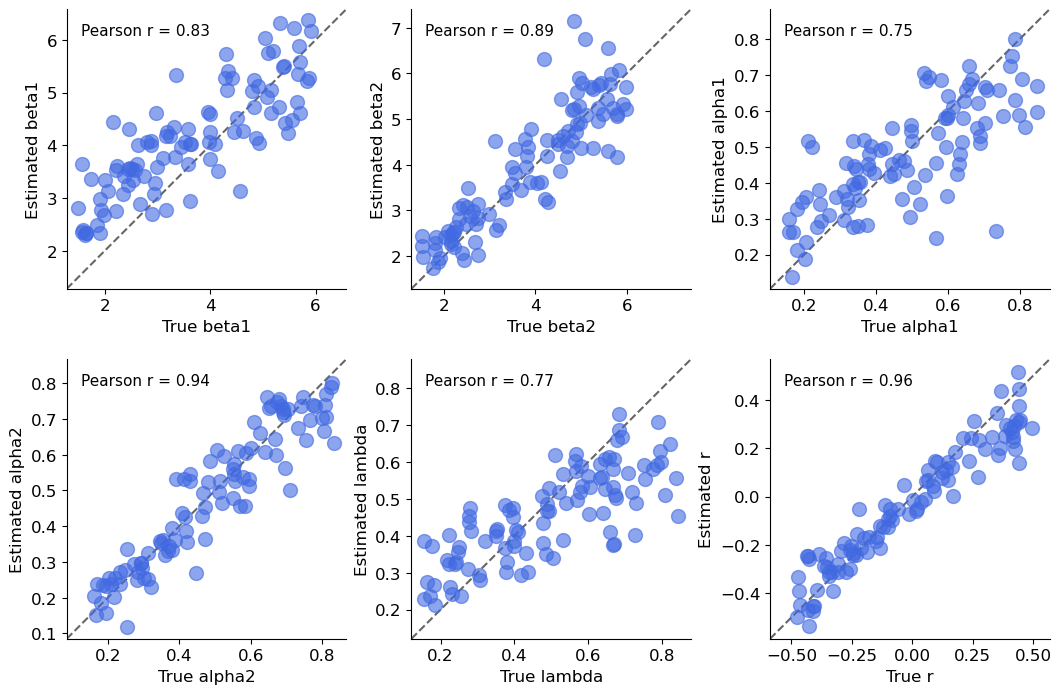

In [4]:
model = EMModel(all_data=None, fit_func=sarsa_lambda_model.fit,
                param_names=param_names, param_xform=param_xform,
                simulate_func=sarsa_lambda_model.sim)

recovery = model.recover(true_params, pr_inputs=PR_INPUTS, ntrials=ntrials)
fig = model.plot_recovery(recovery)

<hr>

## Model-Based: Bellman ($\omega = 1$)

With $\omega = 1$ the model-free first-stage values never enter the choice, so `alpha1` and `lambda` are unidentifiable and drop out.

Free parameters: `beta1`, `beta2`, `alpha2`, `r`.

In [5]:
from pyem.models.rl_mb import model_based_model

print(f"Model ID   : {model_based_model.id}")
print(f"Description: {model_based_model.desc}")
print(f"Spec       : {model_based_model.spec}")

Model ID   : model_based
Description: Model-based Bellman learner for the Daw et al. (2011)
two-step task (w = 1 special case of the hybrid). First-stage values are
recomputed each trial from the (count-estimated) transition structure and the
learned second-stage values via Bellman's equation; choices are softmax with
first-stage perseveration. Because the model-free first-stage values never
enter the choice, alpha1 and lambda drop out. Free parameters: beta1, beta2,
alpha2, r.
Spec       : {'rl': {'softmax': ['beta1', 'beta2'], 'bellman': ['alpha2'], 'choice': ['r']}}


In [6]:
param_names = ["beta1", "beta2", "alpha2", "r"]
param_xform = [XFORM[n] for n in param_names]
true_params = draw_true_params(param_names)

recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].


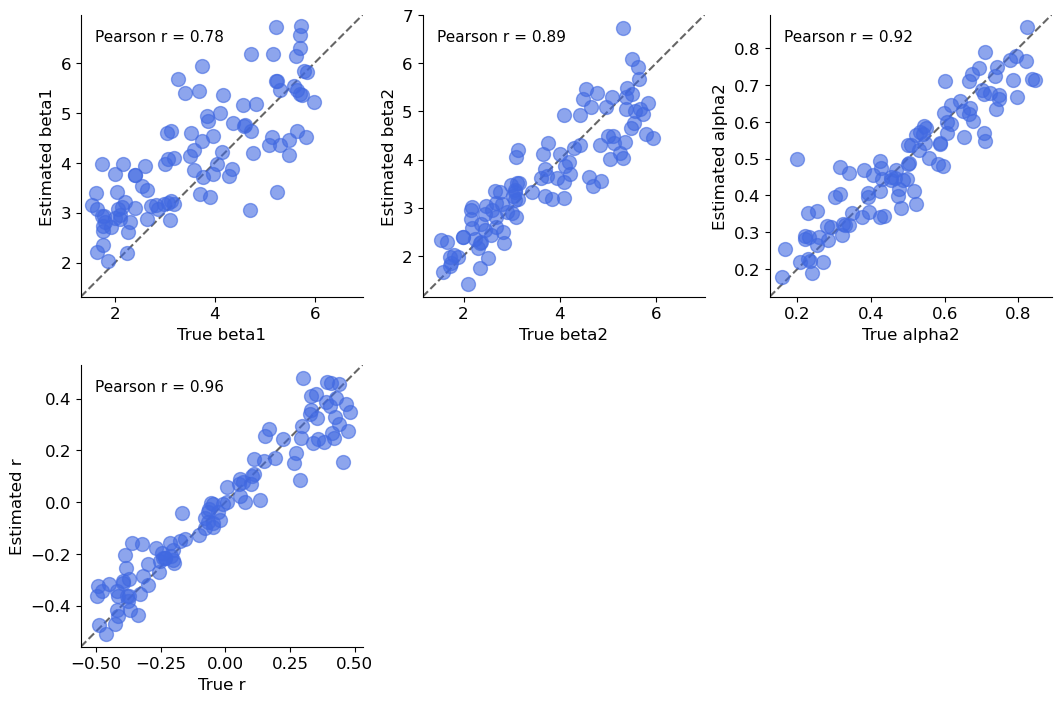

In [7]:
model = EMModel(all_data=None, fit_func=model_based_model.fit,
                param_names=param_names, param_xform=param_xform,
                simulate_func=model_based_model.sim)

recovery = model.recover(true_params, pr_inputs=PR_INPUTS, ntrials=ntrials)
fig = model.plot_recovery(recovery)

<hr>

## Hybrid Model-Based / Model-Free ($\omega$ free)

The full 7-parameter model of Daw et al. (2011).

Free parameters: `beta1`, `beta2`, `alpha1`, `alpha2`, `lambda`, `omega`, `r`.

In [8]:
from pyem.models.rl_mb import hybrid_mbmf_model

print(f"Model ID   : {hybrid_mbmf_model.id}")
print(f"Description: {hybrid_mbmf_model.desc}")
print(f"Spec       : {hybrid_mbmf_model.spec}")

Model ID   : hybrid_mbmf
Description: Hybrid model-based / model-free learner for the Daw et al.
(2011) two-step task (llm2b2alr.m). First-stage net values are a
weighted sum of model-based (Bellman) and model-free (SARSA(lambda)) values,
w*Q_MB + (1-w)*Q_MF, plus first-stage perseveration; choices at both stages are
softmax over these values. Nests the pure model-free (omega=0) and model-based
(omega=1) learners. Free parameters: beta1, beta2, alpha1, alpha2, lambda,
omega, r.
Spec       : {'rl': {'softmax': ['beta1', 'beta2'], 'sarsa': ['alpha1', 'alpha2', 'lambda'], 'weight': ['omega'], 'choice': ['r']}}


In [9]:
param_names = ["beta1", "beta2", "alpha1", "alpha2", "lambda", "omega", "r"]
param_xform = [XFORM[n] for n in param_names]
true_params = draw_true_params(param_names)

recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].


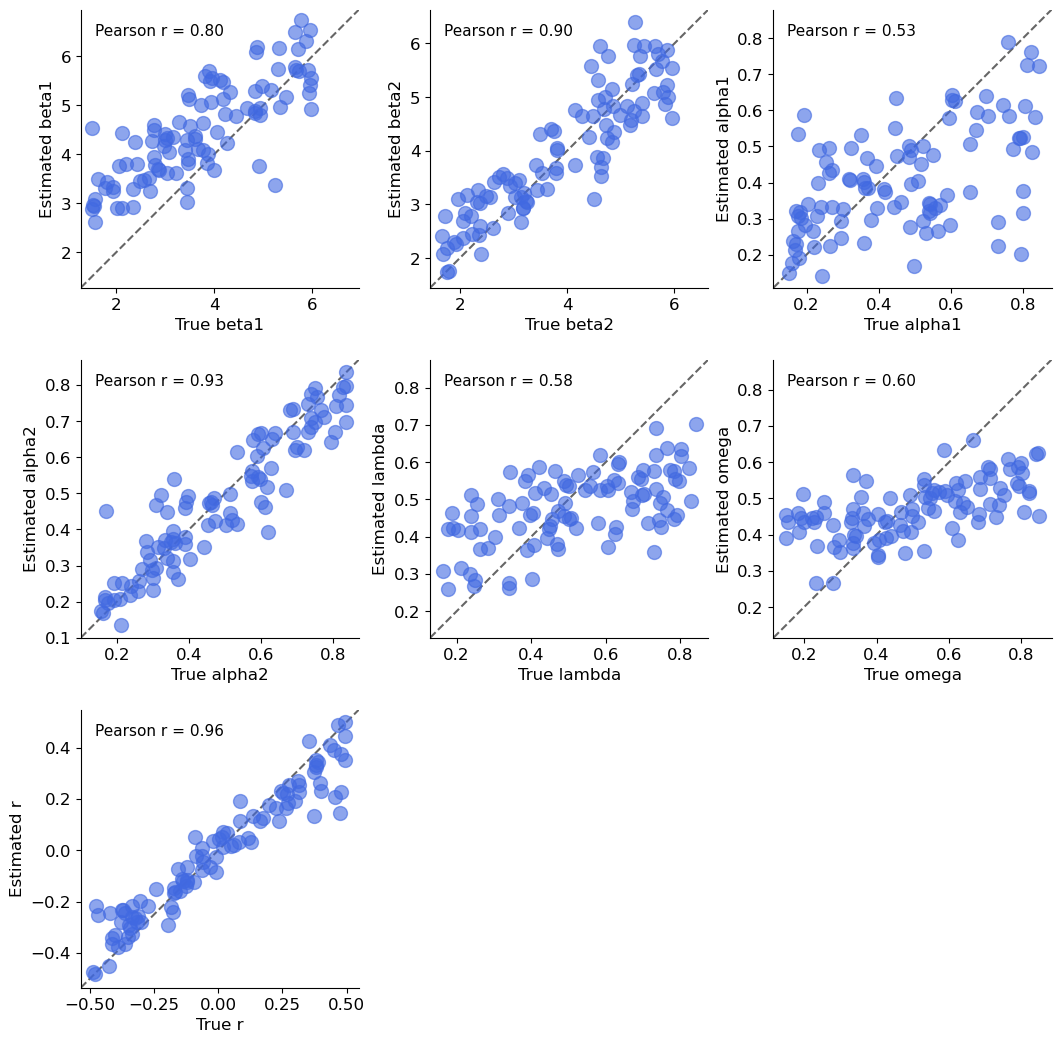

In [10]:
model = EMModel(all_data=None, fit_func=hybrid_mbmf_model.fit,
                param_names=param_names, param_xform=param_xform,
                simulate_func=hybrid_mbmf_model.sim)

recovery = model.recover(true_params, pr_inputs=PR_INPUTS, ntrials=ntrials)
fig = model.plot_recovery(recovery)

<hr>

**Reference**

Daw, N. D., Gershman, S. J., Seymour, B., Dayan, P., & Dolan, R. J. (2011).
Model-based influences on humans' choices and striatal prediction errors.
*Neuron*, 69(6), 1204-1215. https://doi.org/10.1016/j.neuron.2011.02.027